In [1]:
import pandas as pd

In [13]:
df=pd.read_csv('sample_50000.csv') # загружаем выборку
df.head()

,shipment_id,carrier,origin_port,destination_port,transport_mode,status,goods_category,currency,created_date,eta_date,...,freight_cost_usd,num_containers,num_stops,delay_hours,risk_score,weather_severity,port_congestion,temperature_c,priority_level,insurance_required
0,SHP-103243220,Hapag-Lloyd,Guangzhou,Felixstowe,air,On_Schedule,Machinery,SGD,2022-03-15,2022-03-17,...,43376.98,4,4,0.0,0.3746,0.2212,0.1861,NaN,3,True
1,SHP-100992986,ZIM,Antwerp,Savannah,sea,In_Transit,Pharmaceuticals,EUR,2023-11-01,2023-11-11,...,86.78,20,5,0.0,0.1461,0.4391,0.5019,NaN,2,True
2,SHP-100155396,HMM,Sydney,Barcelona,sea,At_Port,Automotive,EUR,2024-08-25,2024-09-06,...,1191.33,21,1,0.0,0.0250,0.2681,0.2048,-0.0,1,True
3,SHP-101216903,FedEx,Rotterdam,Piraeus,sea,Customs_Hold,Food_Beverage,USD,2022-10-08,2022-11-05,...,49996.43,1,4,0.0,0.6754,0.0185,0.2274,NaN,1,True
4,SHP-103930952,DB_Schenker,Jebel_Ali,Rotterdam,sea,On_Schedule,Raw_Materials,AED,2023-05-06,2023-05-26,...,6090.75,6,1,0.0,0.1988,0.1598,0.5593,NaN,1,True


In [14]:
df.isnull().sum() # проверяем пропуски

shipment_id               0
carrier                   0
origin_port               0
destination_port          0
transport_mode            0
status                    0
goods_category            0
currency                  0
created_date              0
eta_date                  0
transit_hours             0
distance_km               0
weight_kg                 0
volume_m3                 0
value_usd                 0
freight_cost_usd          0
num_containers            0
num_stops                 0
delay_hours               0
risk_score                0
weather_severity          0
port_congestion           0
temperature_c         35107
priority_level            0
insurance_required        0
dtype: int64

In [15]:
df.isnull().mean()*100 # проверяем пропуски в %

shipment_id            0.000
carrier                0.000
origin_port            0.000
destination_port       0.000
transport_mode         0.000
status                 0.000
goods_category         0.000
currency               0.000
created_date           0.000
eta_date               0.000
transit_hours          0.000
distance_km            0.000
weight_kg              0.000
volume_m3              0.000
value_usd              0.000
freight_cost_usd       0.000
num_containers         0.000
num_stops              0.000
delay_hours            0.000
risk_score             0.000
weather_severity       0.000
port_congestion        0.000
temperature_c         70.214
priority_level         0.000
insurance_required     0.000
dtype: float64

In [16]:
df.duplicated().sum # проверяем дубликаты

<bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Length: 50000, dtype: bool>

In [17]:
df.info() # оценка структуры файла

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   shipment_id         50000 non-null  str    
 1   carrier             50000 non-null  str    
 2   origin_port         50000 non-null  str    
 3   destination_port    50000 non-null  str    
 4   transport_mode      50000 non-null  str    
 5   status              50000 non-null  str    
 6   goods_category      50000 non-null  str    
 7   currency            50000 non-null  str    
 8   created_date        50000 non-null  str    
 9   eta_date            50000 non-null  str    
 10  transit_hours       50000 non-null  float64
 11  distance_km         50000 non-null  float64
 12  weight_kg           50000 non-null  float64
 13  volume_m3           50000 non-null  float64
 14  value_usd           50000 non-null  float64
 15  freight_cost_usd    50000 non-null  float64
 16  num_containers 

In [30]:
df = df.drop(columns=['temperature_c']) # слишком много пропусков+ сгенерированные данные исказят= удаляем полностью

KeyError: "['temperature_c'] not found in axis"

In [31]:
df.isnull().sum()

shipment_id           0
carrier               0
origin_port           0
destination_port      0
transport_mode        0
status                0
goods_category        0
currency              0
created_date          0
eta_date              0
transit_hours         0
distance_km           0
weight_kg             0
volume_m3             0
value_usd             0
freight_cost_usd      0
num_containers        0
num_stops             0
delay_hours           0
risk_score            0
weather_severity      0
port_congestion       0
priority_level        0
insurance_required    0
dtype: int64

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   shipment_id         50000 non-null  str    
 1   carrier             50000 non-null  str    
 2   origin_port         50000 non-null  str    
 3   destination_port    50000 non-null  str    
 4   transport_mode      50000 non-null  str    
 5   status              50000 non-null  str    
 6   goods_category      50000 non-null  str    
 7   currency            50000 non-null  str    
 8   created_date        50000 non-null  str    
 9   eta_date            50000 non-null  str    
 10  transit_hours       50000 non-null  float64
 11  distance_km         50000 non-null  float64
 12  weight_kg           50000 non-null  float64
 13  volume_m3           50000 non-null  float64
 14  value_usd           50000 non-null  float64
 15  freight_cost_usd    50000 non-null  float64
 16  num_containers 

In [33]:
df.describe()

,transit_hours,distance_km,weight_kg,volume_m3,value_usd,freight_cost_usd,num_containers,num_stops,delay_hours,risk_score,weather_severity,port_congestion,priority_level
count,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,274.375674,8979.712368,18447.085194,43.048501,4.203385e+05,1.761573e+04,12.493560,2.506500,5.529954,0.285463,0.199867,0.333096,2.506220
std,210.443900,5981.398861,55060.017639,141.645794,1.867956e+06,8.473827e+04,6.914208,1.711787,15.416320,0.159034,0.136732,0.178151,1.118243
min,12.000000,200.300000,1.000000,0.000000,1.000000e+02,5.700000e-01,1.000000,0.000000,0.000000,0.001300,0.000100,0.001700,1.000000
25%,86.500000,3980.000000,770.600000,1.590000,1.542746e+04,5.151325e+02,6.000000,1.000000,0.000000,0.162200,0.092300,0.193100,2.000000
50%,212.950000,7544.250000,2999.050000,6.380000,6.003908e+04,2.138445e+03,13.000000,3.000000,0.000000,0.264100,0.173300,0.313650,3.000000
75%,447.000000,13543.625000,11374.000000,25.190000,2.296360e+05,8.743985e+03,18.000000,4.000000,0.000000,0.388500,0.280400,0.454100,4.000000
max,720.000000,21999.400000,500000.000000,2469.640000,5.000000e+07,3.645516e+06,24.000000,5.000000,237.000000,0.889700,0.847300,0.958000,4.000000


In [153]:
df.to_csv('cleaned_shipments.csv', index=False)

In [44]:
# ищем корреляцию в числовых данных
df.corr(numeric_only=True)['delay_hours'].sort_values(ascending=False)

delay_hours           1.000000
num_containers        0.005830
priority_level        0.005803
distance_km           0.004710
transit_hours         0.004422
weather_severity      0.003728
volume_m3             0.002897
weight_kg             0.002552
num_stops             0.001336
risk_score            0.000648
port_congestion      -0.000005
insurance_required   -0.000574
value_usd            -0.000997
freight_cost_usd     -0.002862
Name: delay_hours, dtype: float64

In [1]:
#  ищем выбросы в категорийных данных

<Axes: xlabel='origin_port', ylabel='delay_hours'>

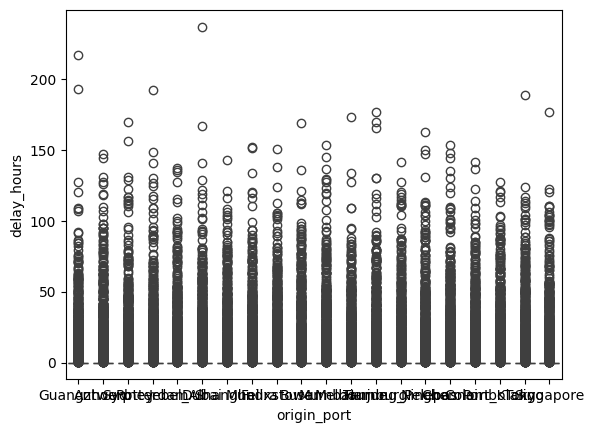

In [83]:
import seaborn as sns
sns.boxplot(data=df, x='origin_port', y='delay_hours')

<Axes: xlabel='destination_port', ylabel='delay_hours'>

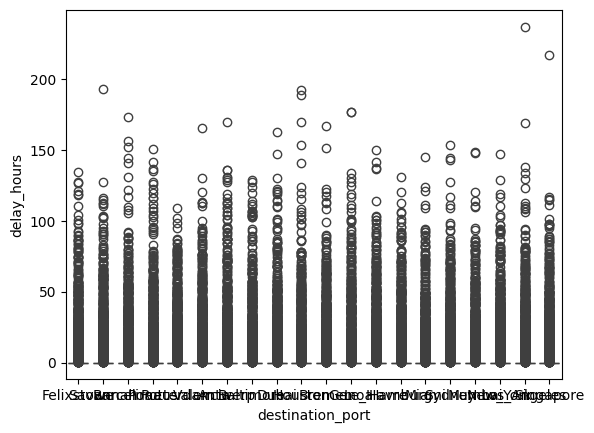

In [37]:
sns.boxplot(data=df, x='destination_port', y='delay_hours')

<Axes: xlabel='carrier', ylabel='delay_hours'>

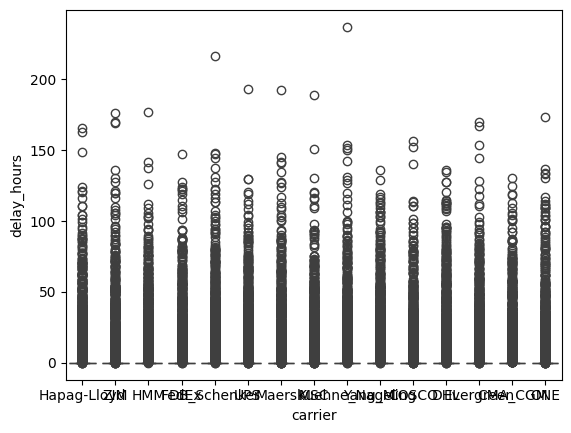

In [39]:
sns.boxplot(data=df, x='carrier', y='delay_hours')

In [141]:
carriers =df['carrier'].unique()
num_carriers=len(carriers)
carriers, num_carriers

(<ArrowStringArray>
 [ 'Hapag-Lloyd',          'ZIM',          'HMM',        'FedEx',
   'DB_Schenker',          'UPS',       'Maersk',          'MSC',
  'Kuehne_Nagel',    'Yang_Ming',        'COSCO',          'DHL',
     'Evergreen',      'CMA_CGM',          'ONE']
 Length: 15, dtype: str,
 15)

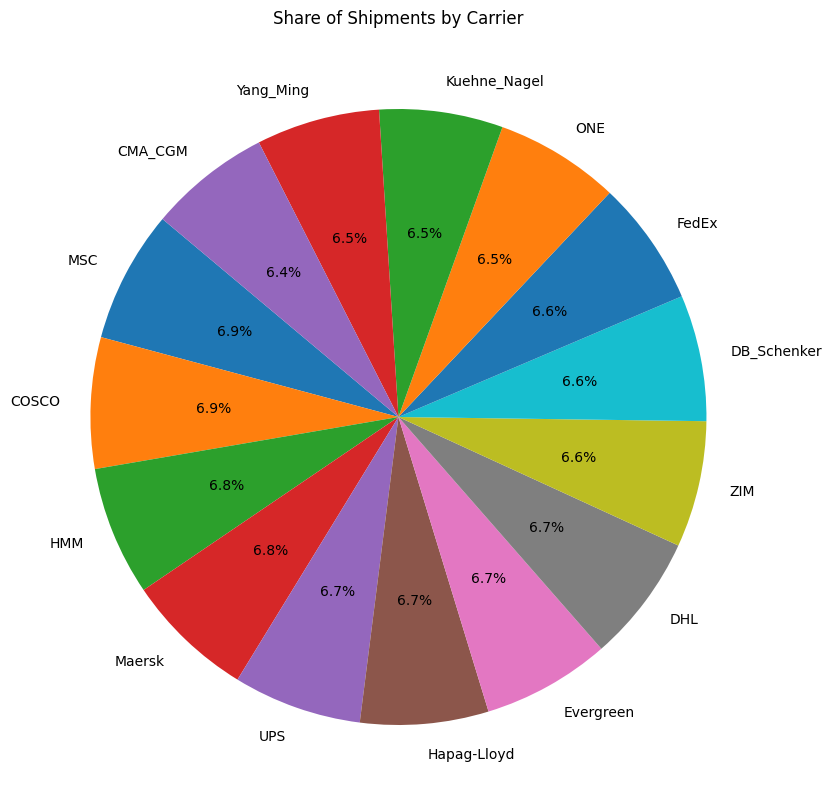

In [143]:
# доля рынка по перевозчикам
carrier_counts=df['carrier'].value_counts()
plt.figure(figsize=(10,10))
plt.pie(carrier_counts, labels=carrier_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Share of Shipments by Carrier')
plt.show()


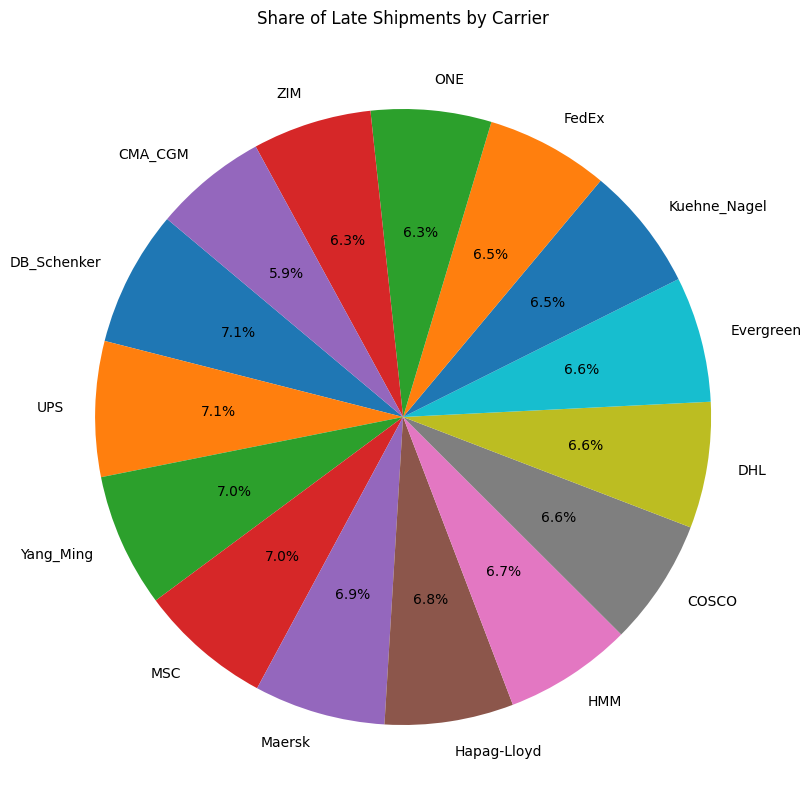

In [5]:
# доля задержек каждого перевозчика
late_df=df[df['delay_hours']>0]
late_carrier_counts=late_df['carrier'].value_counts()
plt.figure(figsize=(10,10))
plt.pie(late_carrier_counts, labels=late_carrier_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Share of Late Shipments by Carrier')
plt.show()        

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('cleaned_shipments.csv')

In [7]:
median_delays = df.groupby('carrier')['delay_hours'].median().reset_index()

C:\Users\jenny\AppData\Local\Temp\ipykernel_14560\2797026981.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=carrier_delay.index,y=carrier_delay.values,palette='Reds_r')


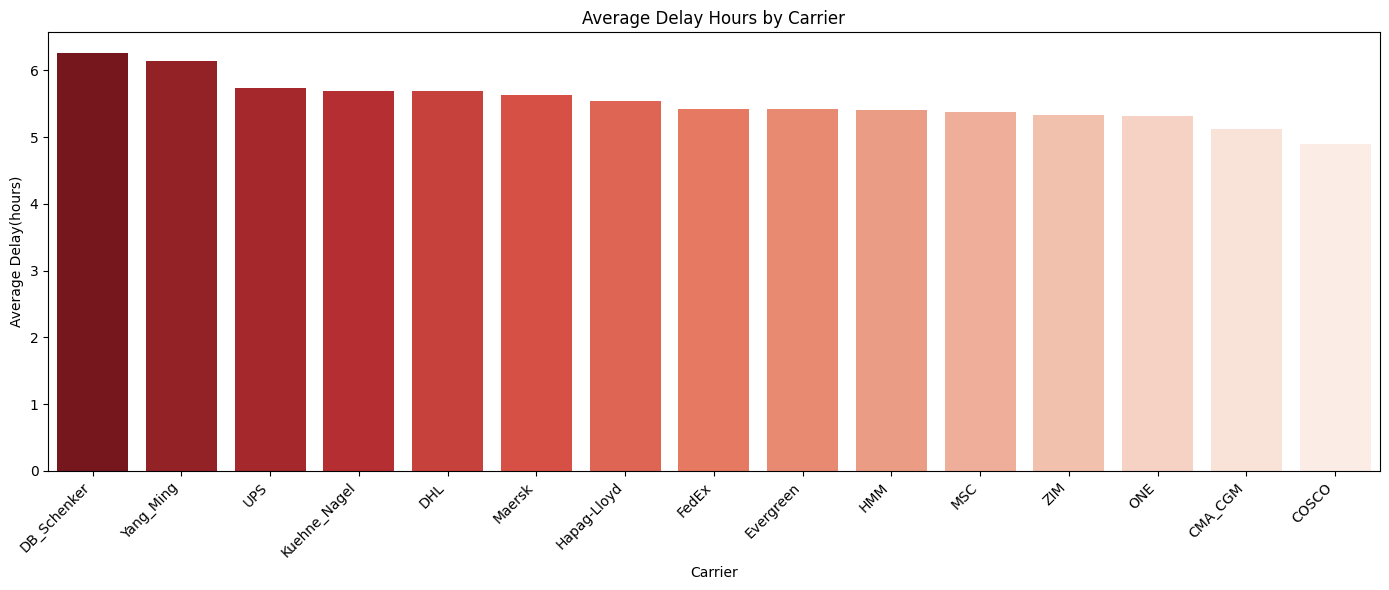

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns
#средняя задержка по каждому перевозчику
carrier_delay=df.groupby('carrier')['delay_hours'].mean().sort_values(ascending=False)
plt.figure(figsize=(14,6))
sns.barplot(x=carrier_delay.index,y=carrier_delay.values,palette='Reds_r')
plt.xticks(rotation=45,ha='right')
plt.title('Average Delay Hours by Carrier')
plt.ylabel('Average Delay(hours)')
plt.xlabel('Carrier')
plt.tight_layout()
plt.show()

<Axes: xlabel='transport_mode', ylabel='delay_hours'>

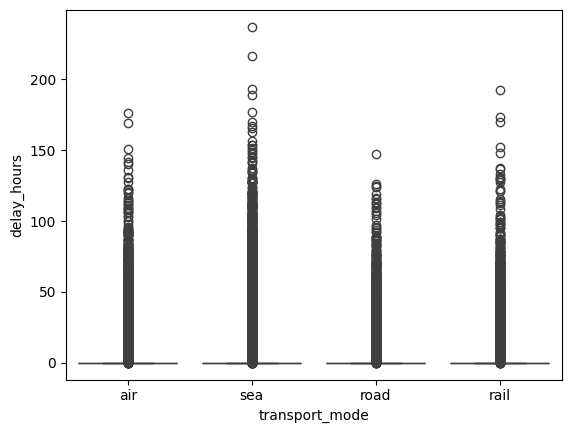

In [40]:
sns.boxplot(data=df, x ='transport_mode', y='delay_hours')

C:\Users\jenny\AppData\Local\Temp\ipykernel_14560\2736124172.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='transport_mode',y='delay_hours',palette='coolwarm')


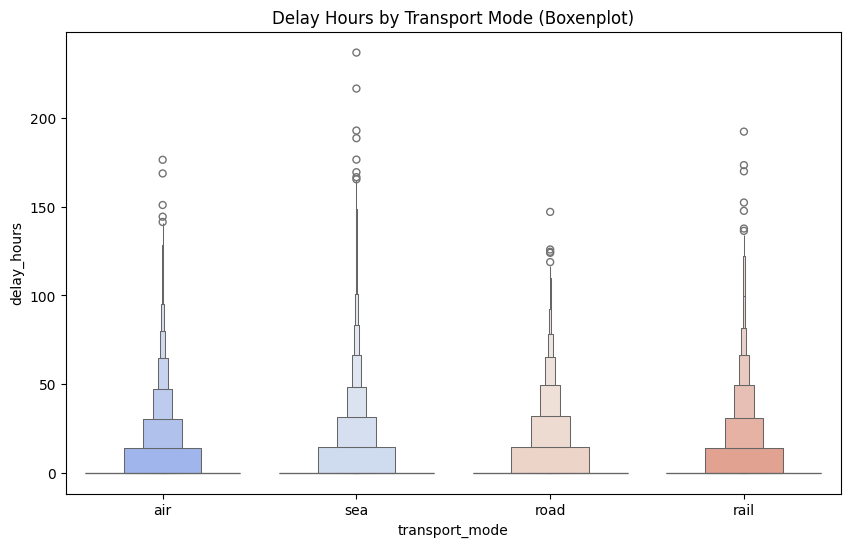

In [151]:
plt.figure(figsize=(10,6))
sns.boxenplot(data=df, x='transport_mode',y='delay_hours',palette='coolwarm')
plt.title('Delay Hours by Transport Mode (Boxenplot)')
plt.show()

In [41]:
# группировка по goods_category
df.groupby('goods_category')['delay_hours'].mean().sort_values(ascending=False)

goods_category
Raw_Materials      5.816416
Electronics        5.815312
Textiles           5.723720
Automotive         5.574016
Food_Beverage      5.541040
Machinery          5.459963
Chemicals          5.401495
Consumer_Goods     5.360692
Pharmaceuticals    5.329514
Perishables        5.273937
Name: delay_hours, dtype: float64

In [43]:
# Heatmap категорий (порт х перевозчик)
df.pivot_table(values='delay_hours',
               index='origin_port',
               columns='carrier',
               aggfunc='mean')
           

carrier,CMA_CGM,COSCO,DB_Schenker,DHL,Evergreen,FedEx,HMM,Hapag-Lloyd,Kuehne_Nagel,MSC,Maersk,ONE,UPS,Yang_Ming,ZIM
origin_port,,,,,,,,,,,,,,,
Antwerp,6.163415,5.176970,6.525568,5.127778,4.883938,4.727848,7.300000,6.687179,5.709091,5.671429,8.296250,3.646795,5.768912,6.762676,6.055844
Busan,4.290503,5.683832,3.949682,6.664000,5.825949,6.242262,4.808642,5.044693,5.408380,6.153005,6.635616,6.050000,7.357485,6.877622,7.140994
Chennai,6.800621,6.482530,7.409143,5.038750,5.728994,7.539888,5.484663,5.542857,6.288571,3.337241,7.176087,5.029375,6.294000,5.131250,3.933939
Colombo,5.055346,5.548824,6.935484,6.123256,6.992500,4.370807,4.741573,6.119653,6.224615,5.469444,5.394767,4.805674,6.362941,4.974342,4.468125
Dubai,4.914110,4.104118,7.292593,4.926946,5.541081,5.270115,5.855208,4.678824,9.494578,5.358278,4.852830,6.180606,8.360000,7.271338,5.963522
Felixstowe,4.426316,4.253297,4.868293,5.961972,6.856213,5.035333,7.002041,5.620859,4.986232,7.532203,4.869318,6.622840,6.147849,6.099425,6.542473
Guangzhou,2.533333,2.934437,6.811351,5.869143,5.834254,5.385417,6.074269,5.304321,7.075000,3.357377,5.111602,3.939444,4.860795,3.847799,4.301130
Hamburg,8.408537,5.047159,6.790196,4.866071,6.712883,4.585161,5.326923,7.738286,3.790286,2.944375,5.439766,3.215625,6.573529,6.430675,5.078049
Jebel_Ali,4.665217,3.896575,7.619318,8.464671,2.243333,4.070588,3.513514,4.250000,6.660140,5.935915,5.996479,4.297126,5.162983,6.840123,3.626012


In [54]:
df.groupby('origin_port')['delay_hours'].mean().sort_values(ascending=False)

origin_port
Dubai              5.973119
Antwerp            5.885496
Ningbo             5.881921
Chennai            5.867194
Mumbai             5.865392
Busan              5.865264
Felixstowe         5.804011
Port_Klang         5.785790
Tokyo              5.632116
Colombo            5.587270
Hamburg            5.534174
Mundra             5.496170
Singapore          5.368573
Rotterdam          5.339205
Shanghai           5.281008
Sydney             5.258792
Tanjung_Pelepas    5.136241
Jebel_Ali          5.114209
Melbourne          5.095316
Guangzhou          4.888589
Name: delay_hours, dtype: float64

In [55]:
df.groupby('destination_port')['delay_hours'].mean().sort_values(ascending=False)

destination_port
Antwerp        6.075235
New_York       5.819369
Dubai          5.749177
Le_Havre       5.652213
Savannah       5.629276
Baltimore      5.607213
Los_Angeles    5.580481
Valencia       5.559411
Singapore      5.558016
Piraeus        5.536924
Bremen         5.527681
Barcelona      5.524591
Felixstowe     5.420367
Genoa          5.419234
Sydney         5.413141
Houston        5.390585
Hamburg        5.353010
Rotterdam      5.348130
Mumbai         5.296574
Miami          5.110776
Name: delay_hours, dtype: float64

In [53]:
df.groupby('carrier')['delay_hours'].mean().sort_values(ascending=False)

carrier
DB_Schenker     6.256639
Yang_Ming       6.134012
UPS             5.740291
Kuehne_Nagel    5.697503
DHL             5.686665
Maersk          5.631498
Hapag-Lloyd     5.541218
FedEx           5.421914
Evergreen       5.414554
HMM             5.401945
MSC             5.380507
ZIM             5.337835
ONE             5.314364
CMA_CGM         5.116552
COSCO           4.901250
Name: delay_hours, dtype: float64

In [46]:
# проверка влияния num_stops
df.groupby('num_stops')['delay_hours'].mean()

num_stops
0    5.528342
1    5.480277
2    5.547779
3    5.514020
4    5.500242
5    5.606489
Name: delay_hours, dtype: float64

In [47]:
#проверка влияния prioryty_level
df.groupby('priority_level')['delay_hours'].mean()

priority_level
1    5.241866
2    5.809528
3    5.428778
4    5.636747
Name: delay_hours, dtype: float64

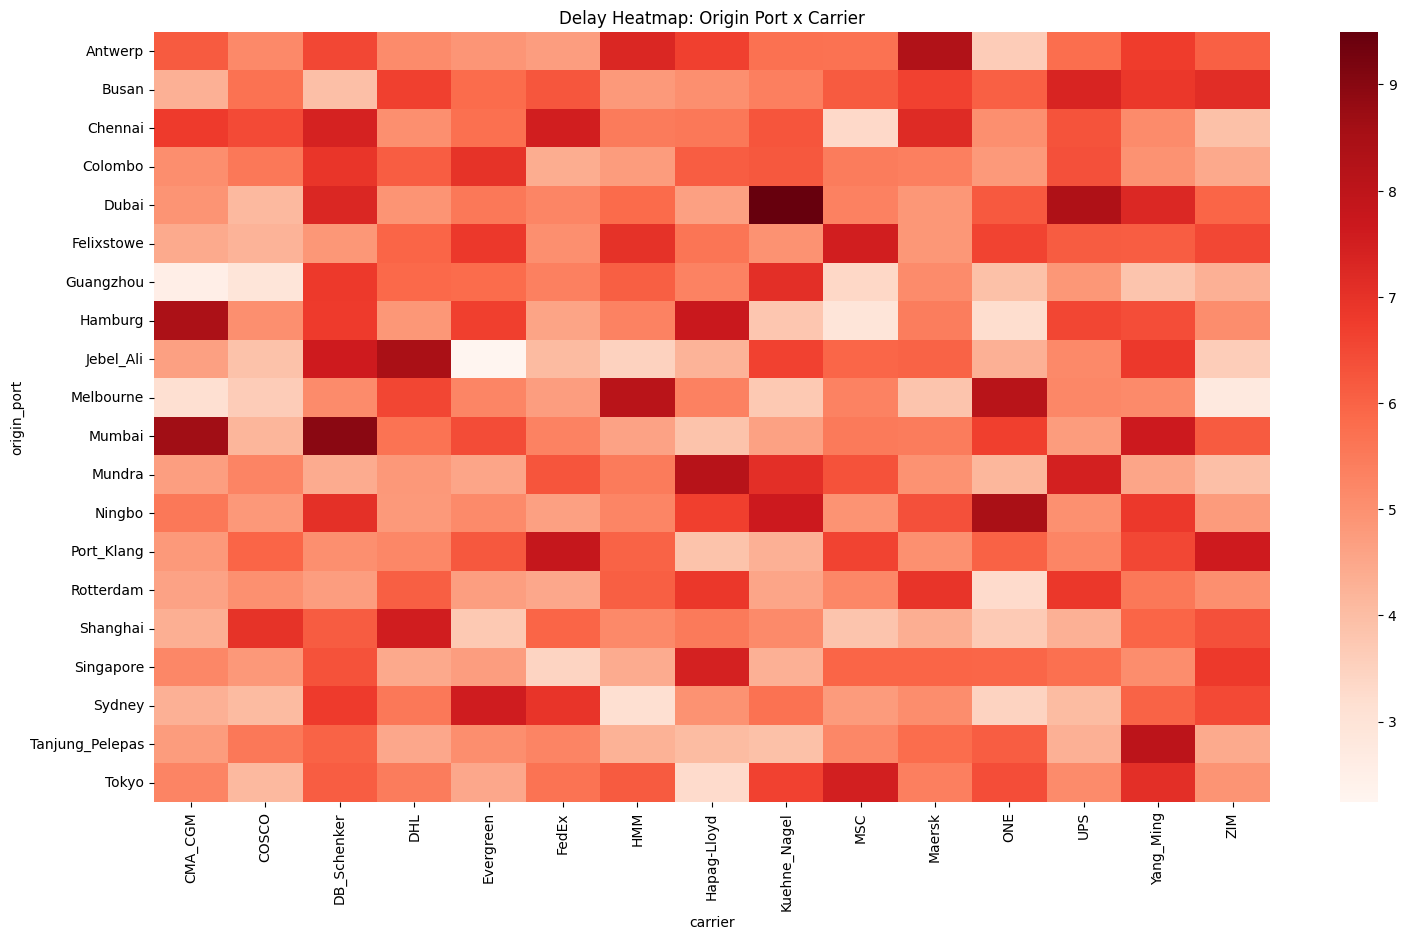

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
pivot=df.pivot_table(values='delay_hours',
                     index='origin_port',
                     columns='carrier',
                     aggfunc='mean')
plt.figure(figsize=(18,10))
sns.heatmap(pivot, cmap='Reds', annot=False)
plt.title('Delay Heatmap: Origin Port x Carrier')
plt.show()

In [60]:
pivot=df.pivot_table(values='delay_hours',
                     index='origin_port',
                     columns='carrier',
                     aggfunc='mean')
top_pairs =pivot.stack().sort_values(ascending=False).head(10)
top_pairs

origin_port  carrier     
Dubai        Kuehne_Nagel    9.494578
Mumbai       DB_Schenker     8.966667
             CMA_CGM         8.639161
Jebel_Ali    DHL             8.464671
Ningbo       ONE             8.460234
Hamburg      CMA_CGM         8.408537
Dubai        UPS             8.360000
Antwerp      Maersk          8.296250
Mundra       Hapag-Lloyd     8.146207
Melbourne    ONE             8.125843
dtype: float64

In [65]:
pivot_dest= df.pivot_table(values='delay_hours',
                           index='destination_port',
                           columns='carrier',
                           aggfunc='mean')
pivot_dest


carrier,CMA_CGM,COSCO,DB_Schenker,DHL,Evergreen,FedEx,HMM,Hapag-Lloyd,Kuehne_Nagel,MSC,Maersk,ONE,UPS,Yang_Ming,ZIM
destination_port,,,,,,,,,,,,,,,
Antwerp,6.221893,4.939444,6.564162,6.234483,7.760897,5.004698,3.331788,7.650000,6.527108,4.216667,5.520904,6.567785,7.222930,4.865089,9.118563
Baltimore,6.582955,5.436313,5.965497,5.582123,6.081522,5.844516,6.427848,4.753571,3.796364,6.242208,5.922857,3.321854,6.353801,8.456684,2.693293
Barcelona,4.646512,6.184865,7.181865,4.509554,5.878646,7.254286,5.453704,2.657233,3.396133,4.809195,7.085714,6.073973,5.407947,6.510303,5.353073
Bremen,4.206329,3.237654,6.355814,6.401258,6.801212,6.205442,7.159551,4.815854,3.596988,5.817610,5.501657,4.730601,6.316071,6.338562,5.421154
Dubai,6.155901,3.833742,6.127152,5.494969,4.903871,6.397452,4.821910,7.873034,6.481988,5.528571,5.607273,6.688554,7.029714,4.459551,4.801775
Felixstowe,5.995109,4.526943,4.442515,6.986154,4.772131,5.035758,3.443537,5.261039,7.100000,4.775316,5.638857,4.871505,5.322086,6.250307,6.654598
Genoa,7.421765,4.618072,5.593478,3.992949,4.832237,3.040252,6.435429,3.592228,3.489103,4.976074,6.652096,7.404878,3.101852,7.749351,8.461006
Hamburg,4.787654,5.513298,8.389583,6.873292,3.596894,3.681757,6.367380,4.552941,6.190132,4.250256,6.193296,4.719333,3.375301,4.330201,7.402778
Houston,5.572000,5.039884,5.483117,4.207018,6.422086,5.950000,3.317978,5.108176,5.708642,7.001695,8.343137,2.390798,4.003743,7.296815,5.683616


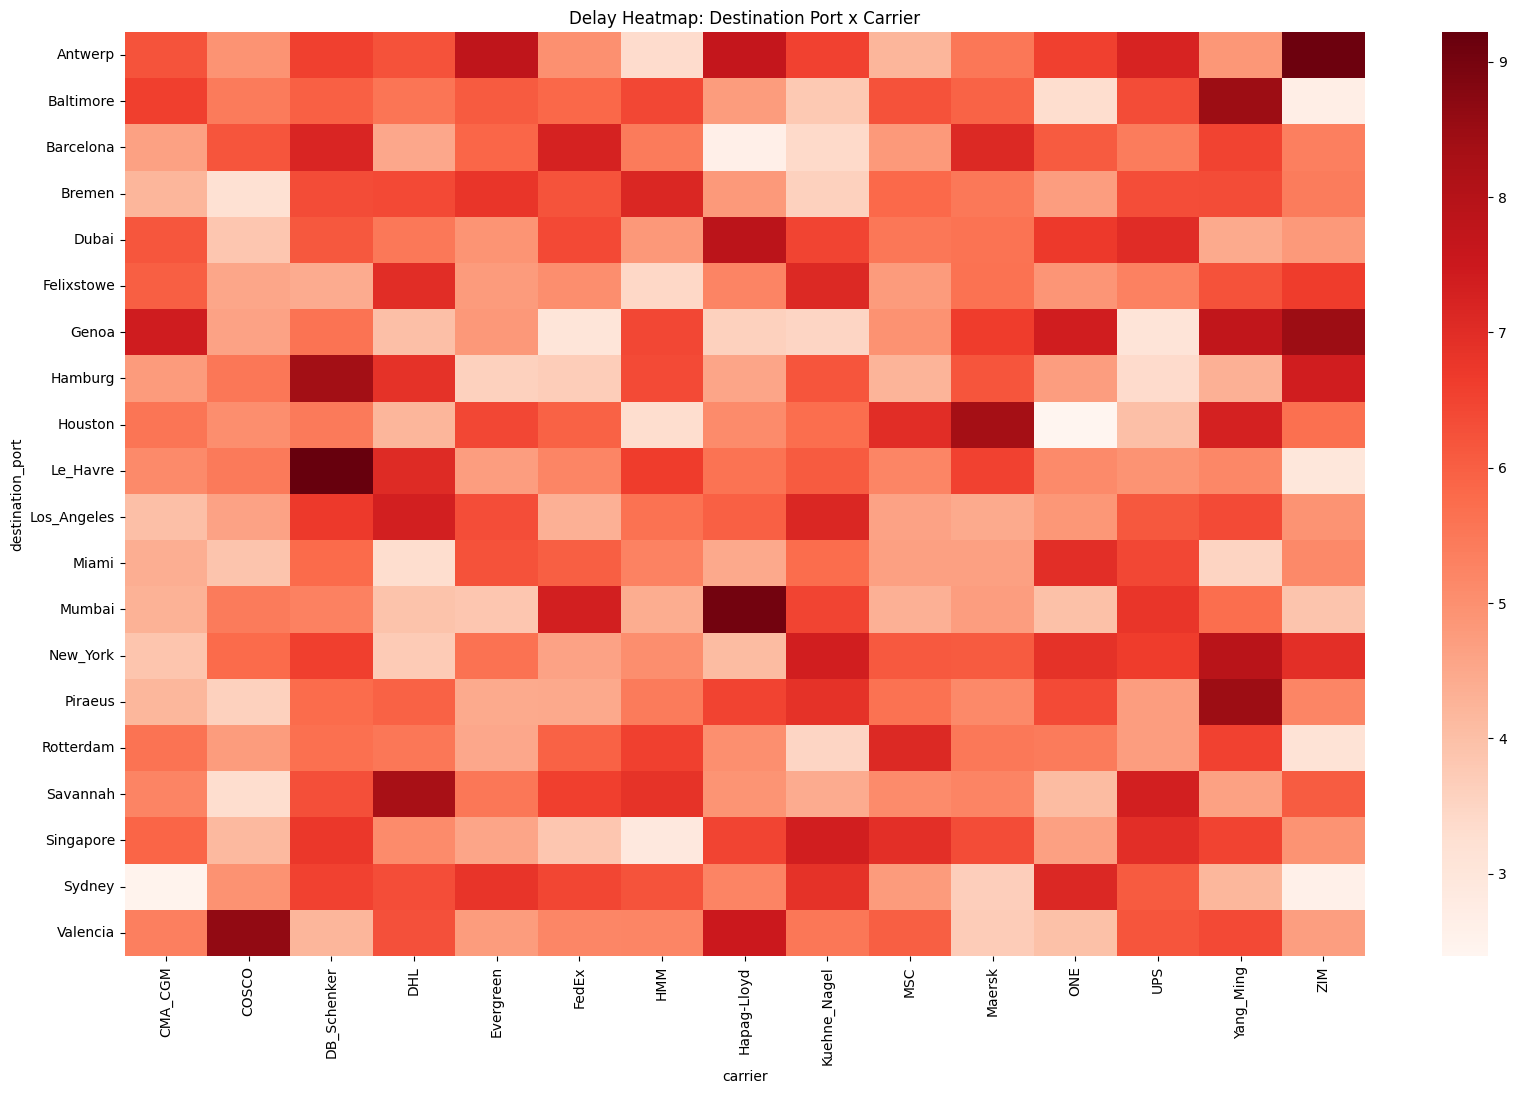

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
pivot_dest=df.pivot_table(values='delay_hours',
                     index='destination_port',
                     columns='carrier',
                     aggfunc='mean')
plt.figure(figsize=(20,12))
sns.heatmap(pivot_dest, cmap='Reds', annot=False)
plt.title('Delay Heatmap: Destination Port x Carrier')
plt.show()

In [69]:
pivot_dest=df.pivot_table(values='delay_hours',
                     index='destination_port',
                     columns='carrier',
                     aggfunc='mean')
top_pairs =pivot_dest.stack().sort_values(ascending=False).head(10)
top_pairs

destination_port  carrier    
Le_Havre          DB_Schenker    9.219231
Antwerp           ZIM            9.118563
Mumbai            Hapag-Lloyd    9.039881
Valencia          COSCO          8.624359
Genoa             ZIM            8.461006
Baltimore         Yang_Ming      8.456684
Piraeus           Yang_Ming      8.450000
Hamburg           DB_Schenker    8.389583
Houston           Maersk         8.343137
Savannah          DHL            8.308743
dtype: float64

In [70]:
triples=df.groupby(['origin_port','carrier','destination_port'])['delay_hours'].mean()
triples.sort_values(ascending=False).head(20)

origin_port  carrier       destination_port
Hamburg      CMA_CGM       Dubai               83.675000
Antwerp      Hapag-Lloyd   Rotterdam           80.700000
Shanghai     COSCO         Singapore           52.233333
Dubai        Kuehne_Nagel  Los_Angeles         49.140000
Rotterdam    UPS           Savannah            44.750000
Chennai      COSCO         Le_Havre            43.725000
             ONE           Antwerp             43.500000
Colombo      DHL           Hamburg             41.166667
Tokyo        Kuehne_Nagel  Dubai               40.000000
Busan        UPS           Singapore           39.637500
Tokyo        Maersk        Houston             39.583333
Hamburg      Yang_Ming     New_York            38.950000
Tokyo        ONE           Piraeus             38.485714
Mumbai       Yang_Ming     Genoa               37.962500
Jebel_Ali    Maersk        Felixstowe          36.075000
Guangzhou    DHL           Valencia            34.600000
Felixstowe   HMM           Los_Angeles      

In [71]:
df.groupby(['transport_mode'])['delay_hours'].mean().sort_values(ascending=False)

transport_mode
sea     5.580453
rail    5.550359
road    5.539070
air     5.345706
Name: delay_hours, dtype: float64

In [140]:
df.groupby(['origin_port','carrier','destination_port','transport_mode'])['delay_hours'].mean().sort_values(ascending=False).head(30)

origin_port      carrier       destination_port  transport_mode
Rotterdam        Maersk        Houston           rail              192.40
Busan            ZIM           Los_Angeles       air               168.80
Chennai          DB_Schenker   Mumbai            rail              147.70
Ningbo           FedEx         New_York          road              147.10
Felixstowe       HMM           Los_Angeles       rail              137.70
Mumbai           ONE           Le_Havre          rail              136.40
Melbourne        ONE           Los_Angeles       rail              133.50
Antwerp          Kuehne_Nagel  Antwerp           rail              131.20
Chennai          ONE           Antwerp           air               130.50
Rotterdam        UPS           Valencia          rail              129.90
Mumbai           Yang_Ming     Baltimore         rail              129.00
Rotterdam        CMA_CGM       Genoa             road              124.60
Colombo          Evergreen     Piraeus          

In [75]:
df['created_date']=pd.to_datetime(df['created_date'])
df['month']=df['created_date'].dt.month
df.groupby('month')['delay_hours'].mean().sort_values(ascending=False)

month
9     5.879446
6     5.782622
7     5.666113
2     5.623608
1     5.617304
11    5.588290
4     5.451601
10    5.440832
3     5.424147
5     5.344664
8     5.326018
12    5.249313
Name: delay_hours, dtype: float64

In [76]:
df['weekday'] =df['created_date'].dt.dayofweek
df.groupby('weekday')['delay_hours'].mean()

weekday
0    5.405621
1    5.716353
2    5.430278
3    5.425691
4    5.497661
5    5.421079
6    5.815626
Name: delay_hours, dtype: float64

In [78]:
df['quarter'] =df['created_date'].dt.quarter
df.groupby('quarter')['delay_hours'].mean()

quarter
1    5.553123
2    5.520729
3    5.619630
4    5.424383
Name: delay_hours, dtype: float64

In [80]:
df['month'] =df['created_date'].dt.month
df['season']=df['month'].map({
    12:'winter', 1:'winter', 2:'winter',
    3:'spring',4:'spring',5:'spring',
    6:'summer',7:'summer',8:'summer',
    9:'autumn',10:'autumn',11:'autumn'
})
df.groupby('season')['delay_hours'].mean()

season
autumn    5.637652
spring    5.406020
summer    5.585501
winter    5.492564
Name: delay_hours, dtype: float64

In [81]:
df['is_christmas'] =df['created_date'].dt.month.isin([12,1])
df.groupby('is_christmas')['delay_hours'].mean()

is_christmas
False    5.549706
True     5.431926
Name: delay_hours, dtype: float64

In [82]:
df['is_cny']=df['created_date'].dt.month==2
df.groupby('is_cny')['delay_hours'].mean()

is_cny
False    5.522075
True     5.623608
Name: delay_hours, dtype: float64

In [84]:
weakest=df.groupby(
    ['origin_port', 'carrier', 'destination_port', 'transport_mode']
)['delay_hours'].mean().sort_values(ascending=False).head(10)
weakest

origin_port  carrier       destination_port  transport_mode
Rotterdam    Maersk        Houston           rail              192.4
Busan        ZIM           Los_Angeles       air               168.8
Chennai      DB_Schenker   Mumbai            rail              147.7
Ningbo       FedEx         New_York          road              147.1
Felixstowe   HMM           Los_Angeles       rail              137.7
Mumbai       ONE           Le_Havre          rail              136.4
Melbourne    ONE           Los_Angeles       rail              133.5
Antwerp      Kuehne_Nagel  Antwerp           rail              131.2
Chennai      ONE           Antwerp           air               130.5
Rotterdam    UPS           Valencia          rail              129.9
Name: delay_hours, dtype: float64

In [99]:
# Задержки
min_delay=df['delay_hours'].min()
max_delay=df['delay_hours'].max
min_delay, max_delay

(np.float64(0.0),
 <bound method Series.max of 0         0.0
 1         0.0
 2         0.0
 3         0.0
 4         0.0
          ... 
 49995    29.3
 49996     0.0
 49997     0.0
 49998     0.0
 49999     0.0
 Name: delay_hours, Length: 50000, dtype: float64>)

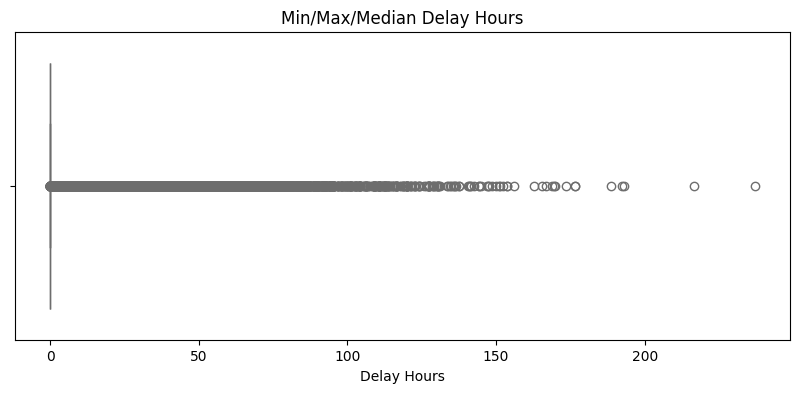

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,4))
sns.boxplot(x=df['delay_hours'],color='salmon')
plt.title('Min/Max/Median Delay Hours')
plt.xlabel('Delay Hours')
plt.show()

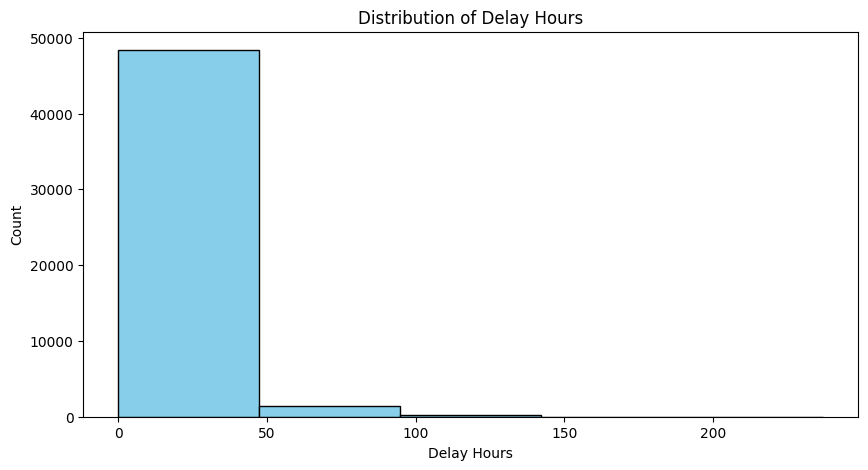

In [110]:
plt.figure(figsize=(10,5))
plt.hist(df['delay_hours'],bins=5,color='skyblue', edgecolor='black')
plt.title('Distribution of Delay Hours')
plt.xlabel('Delay Hours')
plt.ylabel('Count')
plt.show()

In [89]:
#процент опозданий
#общее количество задержек
#средняя задержка в часах
total_shipments=len(df)
late_shipments=(df['delay_hours']>0).sum()
late_shipments

np.int64(11486)

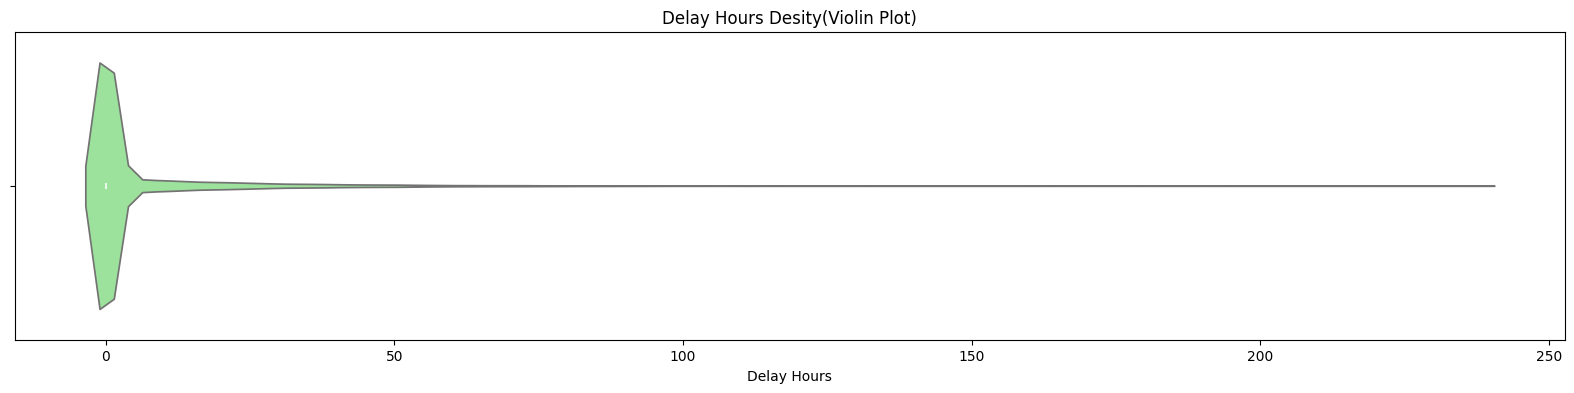

In [113]:
plt.figure(figsize=(20,4))
sns.violinplot(x=df['delay_hours'],color='lightgreen')
plt.title('Delay Hours Desity(Violin Plot)')
plt.xlabel('Delay Hours')
plt.show()

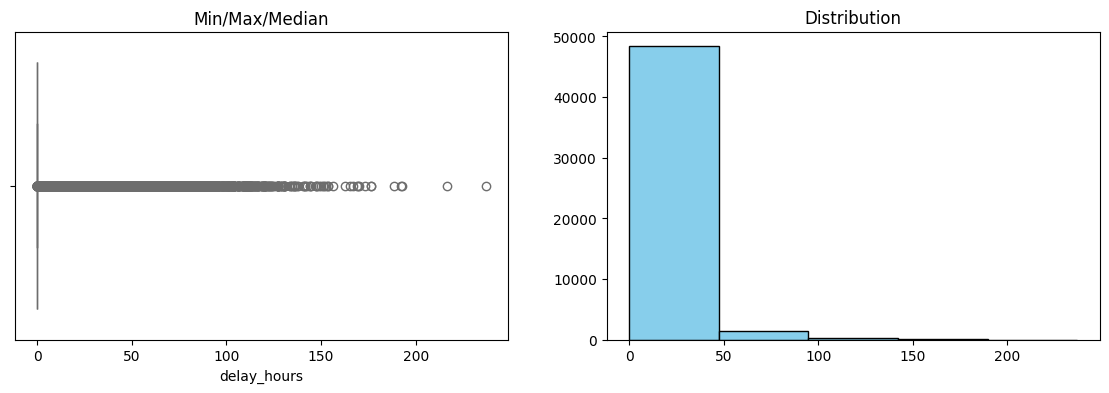

In [124]:
fig, ax=plt.subplots(1,2,figsize=(14,4))
sns.boxplot(x=df['delay_hours'],ax=ax[0], color='salmon')
ax[0].set_title('Min/Max/Median')
ax[1].hist(df['delay_hours'],bins=5,color='skyblue', edgecolor='black')
ax[1].set_title('Distribution')
plt.show()

In [90]:
percent_late=late_shipments/total_shipments*100
percent_late

np.float64(22.972)

In [92]:
total_delay_hours=df['delay_hours'].sum()
total_delay_hours

np.float64(276497.7)

In [93]:
avg_delay=df['delay_hours'].mean()
avg_delay

np.float64(5.529954)

In [95]:
avg_delay_late_only=df.loc[df['delay_hours']>0,'delay_hours'].mean()
avg_delay_late_only

np.float64(24.072584015323002)

<Axes: >

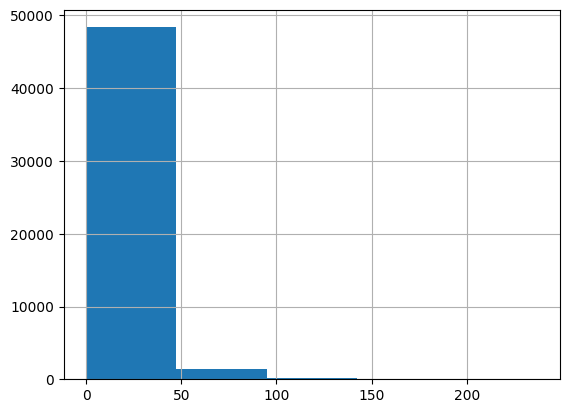

In [126]:
df['delay_hours'].hist(bins=5)

In [129]:
total_shipments=len(df)
late_shipments=(df['delay_hours']>0).sum()
percent_late=late_shipments/total_shipments*100

total_delay_hours=df['delay_hours'].sum()
avg_delay=df['delay_hours'].mean()
avg_delay_late_only=df.loc[df['delay_hours']>0,'delay_hours'].mean()

percent_late, total_delay_hours, avg_delay, avg_delay_late_only


(np.float64(22.972),
 np.float64(276497.7),
 np.float64(5.529954),
 np.float64(24.072584015323002))

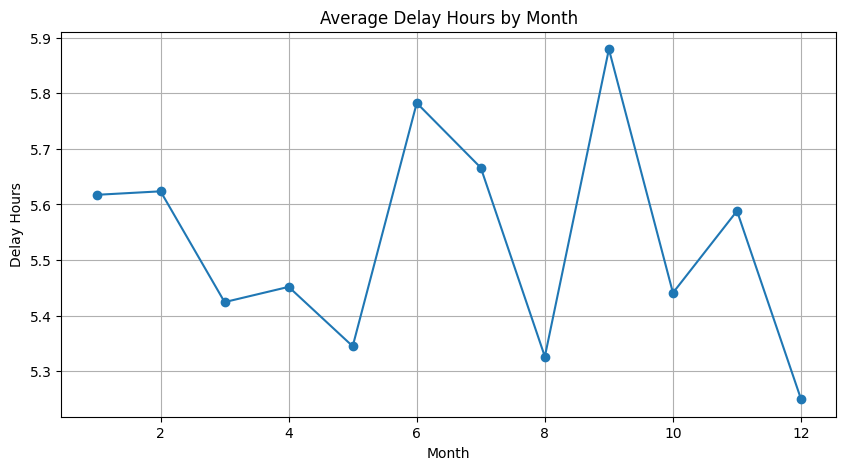

In [133]:
plt.figure(figsize=(10,5))
df.groupby('month')['delay_hours'].mean().plot(kind='line',marker='o')
plt.title('Average Delay Hours by Month')
plt.xlabel('Month')
plt.ylabel('Delay Hours')
plt.grid(True)
plt.show()

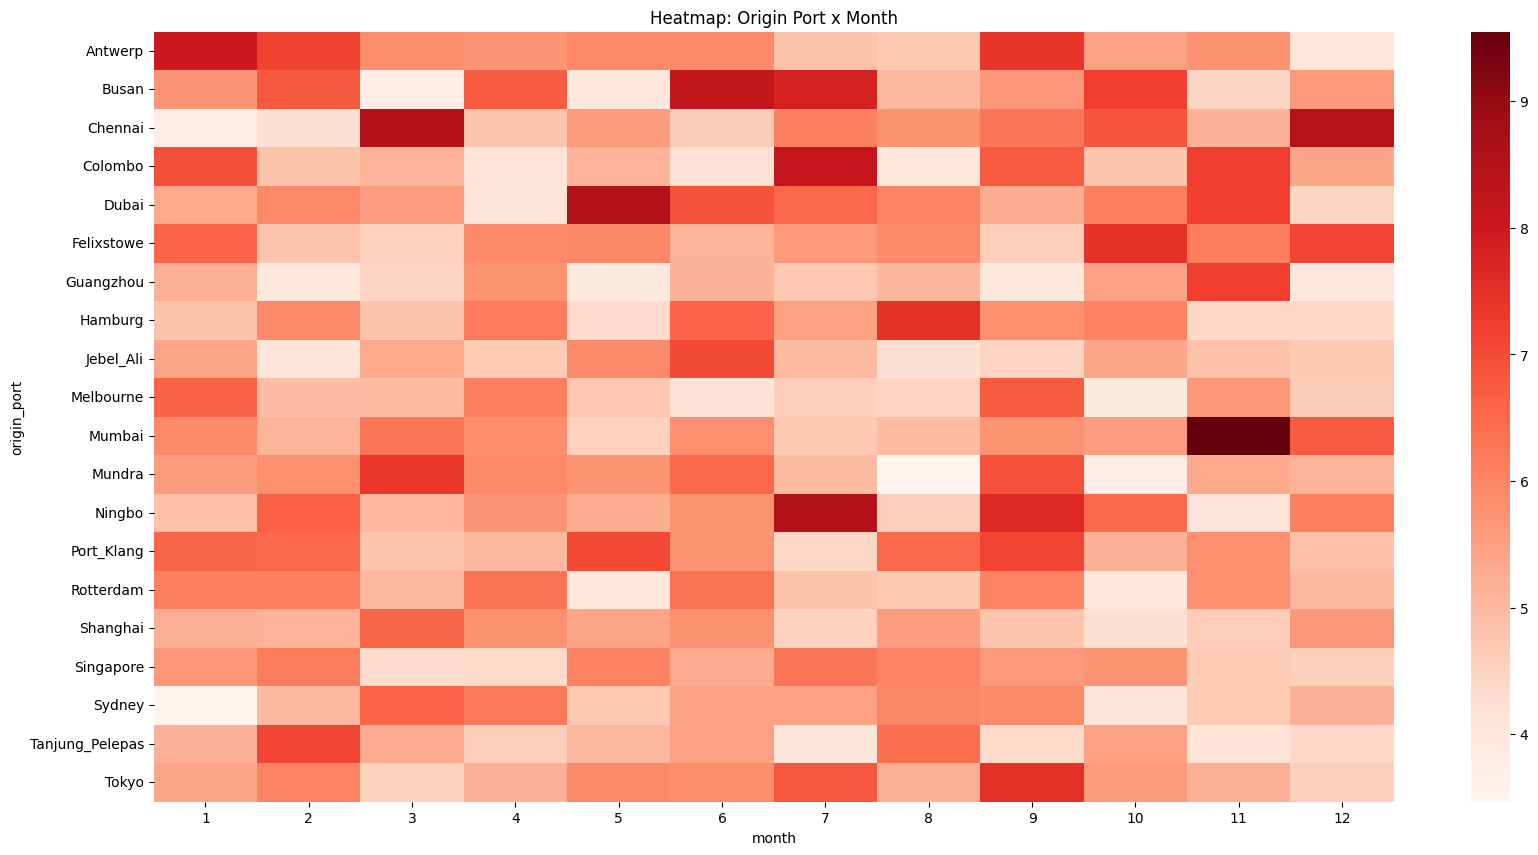

In [138]:
pivot_month_port=df.pivot_table(values='delay_hours',
                                index='origin_port',
                                columns= 'month',
                                aggfunc='mean')
plt.figure(figsize=(20,10))
sns.heatmap(pivot_month_port, cmap='Reds')
plt.title('Heatmap: Origin Port x Month')
plt.show()

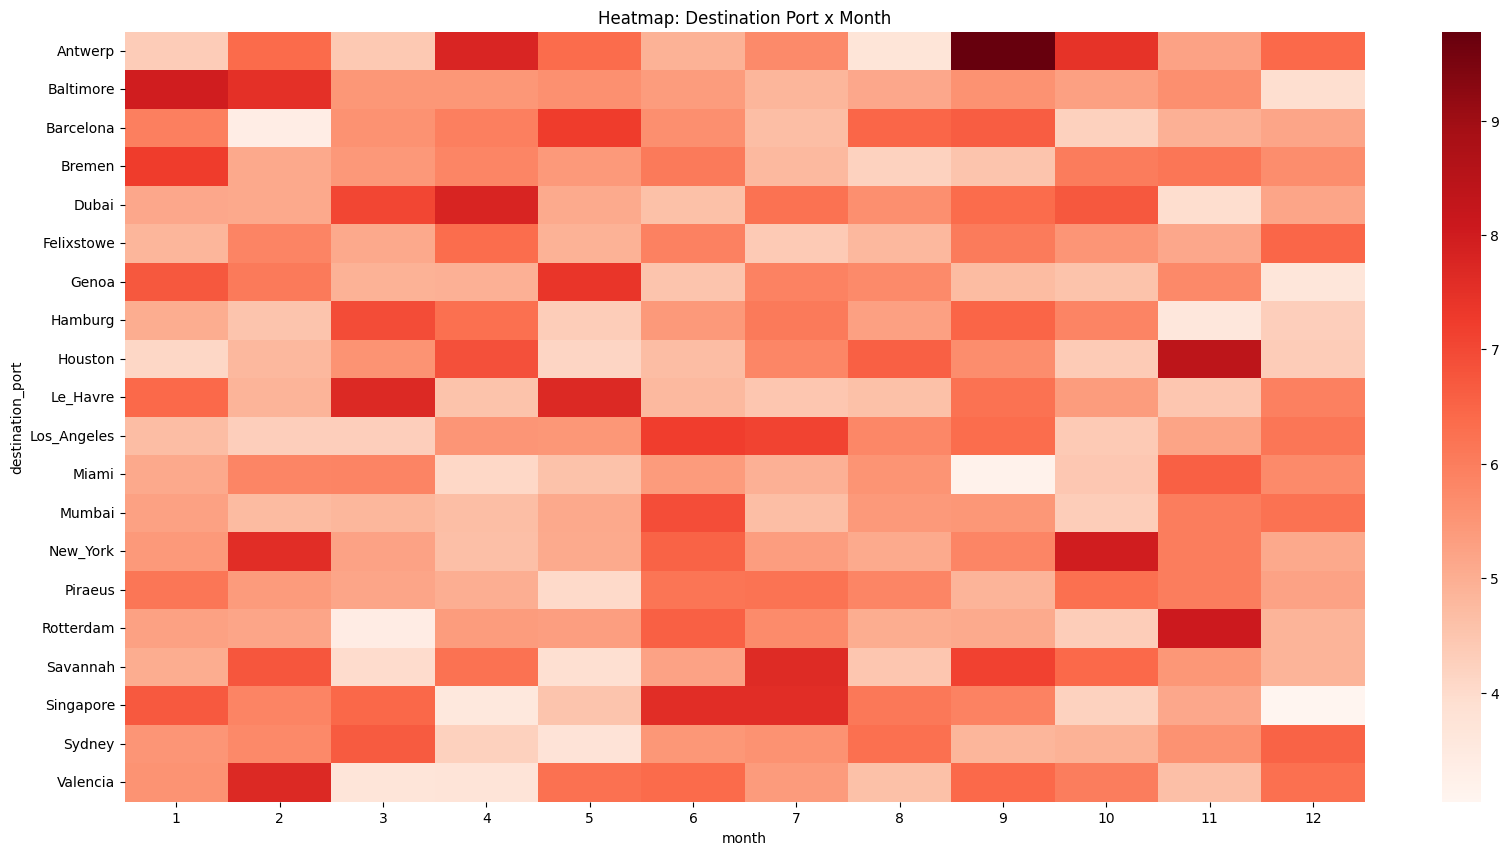

In [139]:
pivot_month_dest=df.pivot_table(values='delay_hours',
                                index='destination_port',
                                columns= 'month',
                                aggfunc='mean')
plt.figure(figsize=(20,10))
sns.heatmap(pivot_month_dest, cmap='Reds')
plt.title('Heatmap: Destination Port x Month')
plt.show()

In [154]:
df=df.drop(columns=['quarater'])

In [155]:
df.columns

Index(['shipment_id', 'carrier', 'origin_port', 'destination_port',
       'transport_mode', 'status', 'goods_category', 'currency',
       'created_date', 'eta_date', 'transit_hours', 'distance_km', 'weight_kg',
       'volume_m3', 'value_usd', 'freight_cost_usd', 'num_containers',
       'num_stops', 'delay_hours', 'risk_score', 'weather_severity',
       'port_congestion', 'priority_level', 'insurance_required', 'month',
       'weekday', 'quarter', 'season', 'is_christmas', 'is_cny'],
      dtype='str')

In [156]:
df.to_csv('cleaned_shipments.csv',index=False)

In [157]:
import os
os.getcwd()

'C:\\Users\\jenny\\DA26_kiki\\test_project\\it_step_project'

In [158]:
import os
os.listdir()

['.ipynb_checkpoints',
 '01_data_cleaning.ipynb',
 'cleaned_shipments.csv',
 'sample_50000.csv']

In [13]:
!pip install matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 6.3 MB/s eta 0:00:02
   ------ --------------------------------- 1.6/9.3 MB 4.9 MB/s eta 0:00:02
   ---------- ----------------------------- 2.4/9.3 MB 4.7 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.3 MB 5.2 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.3 MB 5.2 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.3 MB 5

In [16]:
df=pd.read_csv('cleaned_shipments.csv')
df.head()

,shipment_id,carrier,origin_port,destination_port,transport_mode,status,goods_category,currency,created_date,eta_date,...,weather_severity,port_congestion,priority_level,insurance_required,month,weekday,quarter,season,is_christmas,is_cny
0,SHP-103243220,Hapag-Lloyd,Guangzhou,Felixstowe,air,On_Schedule,Machinery,SGD,2022-03-15,2022-03-17,...,0.2212,0.1861,3,True,3,1,1,spring,False,False
1,SHP-100992986,ZIM,Antwerp,Savannah,sea,In_Transit,Pharmaceuticals,EUR,2023-11-01,2023-11-11,...,0.4391,0.5019,2,True,11,2,4,autumn,False,False
2,SHP-100155396,HMM,Sydney,Barcelona,sea,At_Port,Automotive,EUR,2024-08-25,2024-09-06,...,0.2681,0.2048,1,True,8,6,3,summer,False,False
3,SHP-101216903,FedEx,Rotterdam,Piraeus,sea,Customs_Hold,Food_Beverage,USD,2022-10-08,2022-11-05,...,0.0185,0.2274,1,True,10,5,4,autumn,False,False
4,SHP-103930952,DB_Schenker,Jebel_Ali,Rotterdam,sea,On_Schedule,Raw_Materials,AED,2023-05-06,2023-05-26,...,0.1598,0.5593,1,True,5,5,2,spring,False,False


C:\Users\jenny\AppData\Local\Temp\ipykernel_3192\1461946114.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=carrier_median_delay.index,y=carrier_median_delay.values,palette='Blues_r')


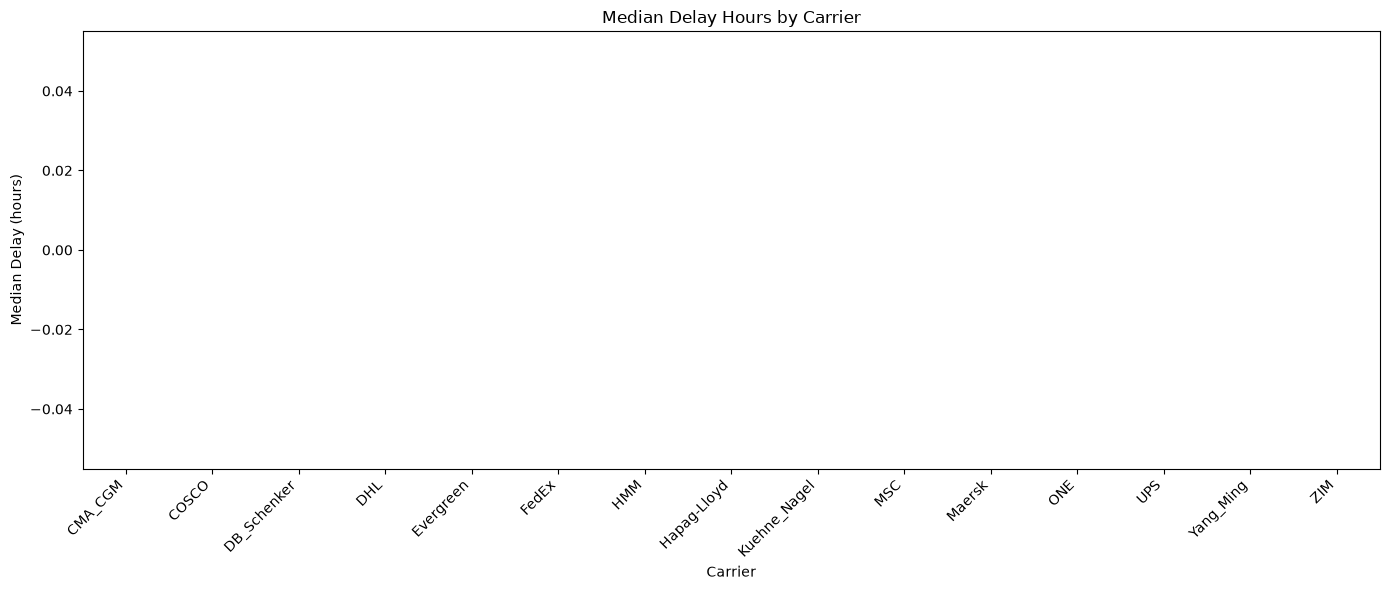

In [17]:
import matplotlib.pyplot as plt
carrier_median_delay=(
    df.groupby('carrier')['delay_hours']
      .median()
      .sort_values(ascending=False)
)
plt.figure(figsize=(14,6))
sns.barplot(x=carrier_median_delay.index,y=carrier_median_delay.values,palette='Blues_r')
plt.xticks(rotation=45, ha='right')
plt.title('Median Delay Hours by Carrier')
plt.ylabel('Median Delay (hours)')
plt.xlabel('Carrier')
plt.tight_layout()
plt.show()

In [20]:
carrier_median_delay=(
    df.groupby('carrier')['delay_hours']
    .median()
    .sort_values(ascending=False)
)

In [21]:
carrier_median_delay.head()

carrier
CMA_CGM        0.0
COSCO          0.0
DB_Schenker    0.0
DHL            0.0
Evergreen      0.0
Name: delay_hours, dtype: float64

In [23]:
carrier_q3_delay=(
    df.groupby('carrier')['delay_hours']
      .quantile(0.75)
      .sort_values(ascending=False)
)

In [24]:
carrier_median_nonzero=(
    df[df['delay_hours']>0]
    .groupby('carrier')['delay_hours']
    .median()
    .sort_values(ascending=False)
)

In [25]:
df['delay_hours'].describe()

count    50000.000000
mean         5.529954
std         15.416320
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        237.000000
Name: delay_hours, dtype: float64

In [26]:
df['delay_hours'].quantile(0.90)

np.float64(19.8)

C:\Users\jenny\AppData\Local\Temp\ipykernel_3192\1574662168.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=carrier_p95.index,y=carrier_p95.values,palette='Greens_r')


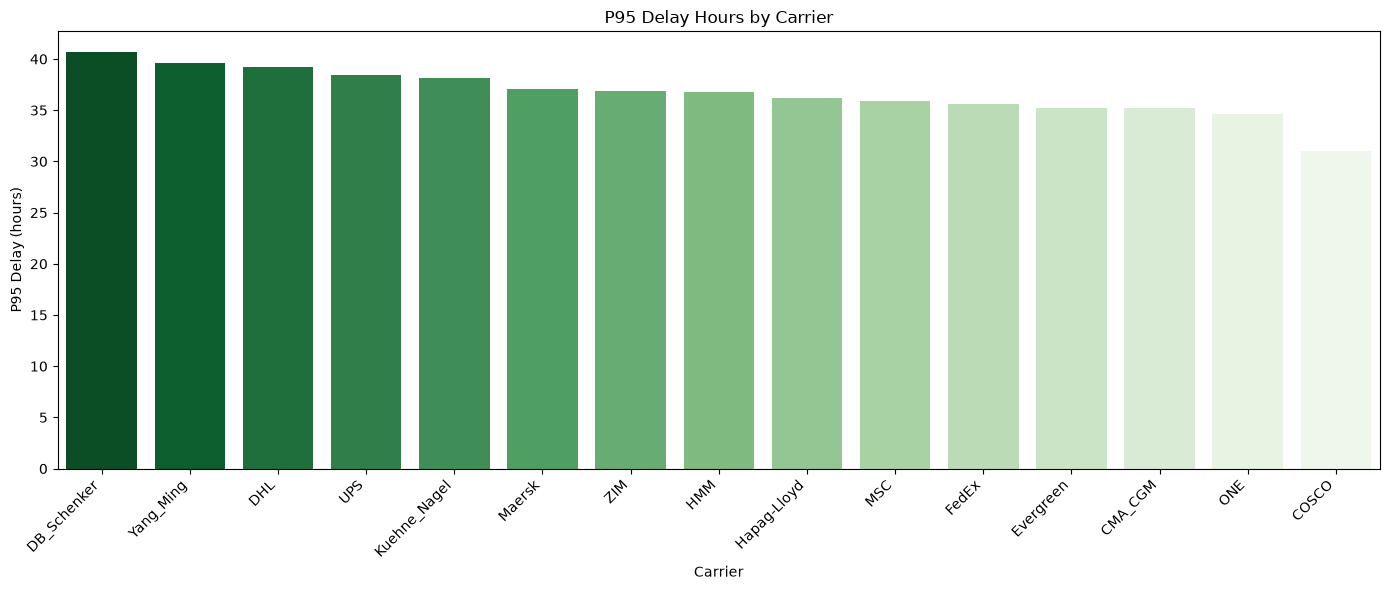

In [39]:
carrier_p95=(
    df.groupby('carrier')['delay_hours']
      .quantile(0.95)
      .sort_values(ascending=False)
)
plt.figure(figsize=(14,6))
sns.barplot(x=carrier_p95.index,y=carrier_p95.values,palette='Greens_r')
plt.xticks(rotation=45, ha='right')
plt.title('P95 Delay Hours by Carrier')
plt.ylabel('P95 Delay (hours)')
plt.xlabel('Carrier')
plt.tight_layout()
plt.show()

C:\Users\jenny\AppData\Local\Temp\ipykernel_3192\1080666393.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=carrier_p90.index,y=carrier_p90.values,palette='Blues_r')


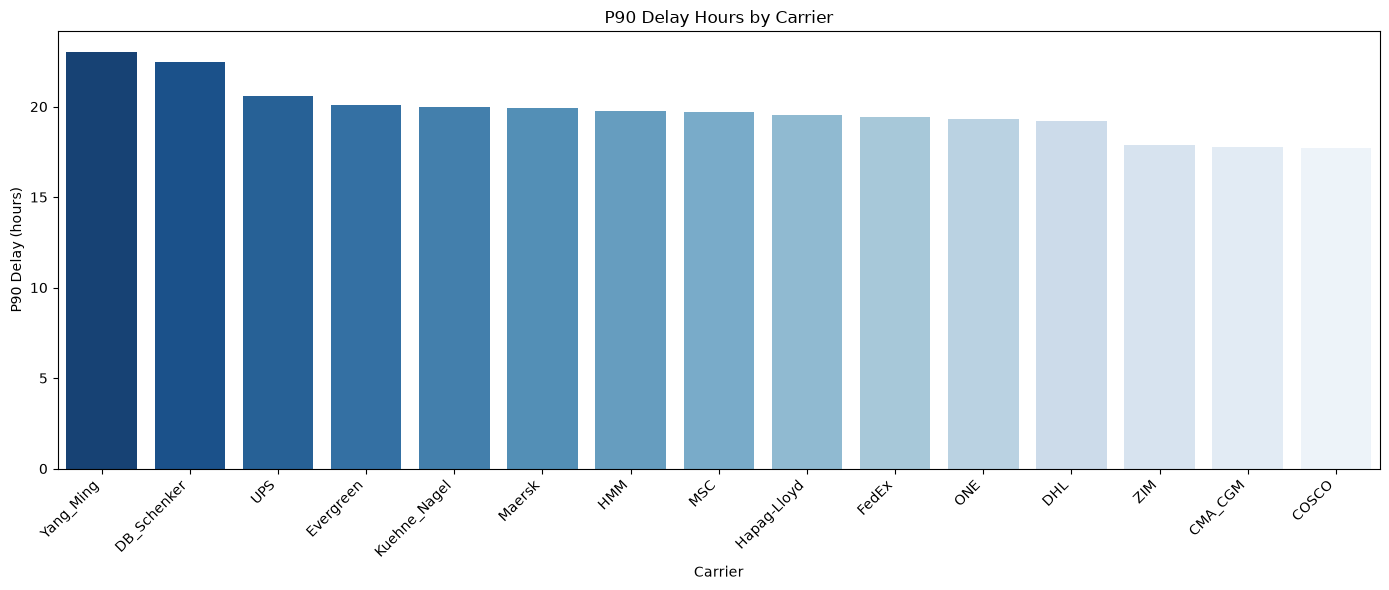

In [27]:
carrier_p90=(
    df.groupby('carrier')['delay_hours']
      .quantile(0.90)
      .sort_values(ascending=False)
)
plt.figure(figsize=(14,6))
sns.barplot(x=carrier_p90.index,y=carrier_p90.values,palette='Blues_r')
plt.xticks(rotation=45, ha='right')
plt.title('P90 Delay Hours by Carrier')
plt.ylabel('P90 Delay (hours)')
plt.xlabel('Carrier')
plt.tight_layout()
plt.show()

C:\Users\jenny\AppData\Local\Temp\ipykernel_3192\3193197334.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=carrier_p99.index,y=carrier_p90.values,palette='Reds_r')


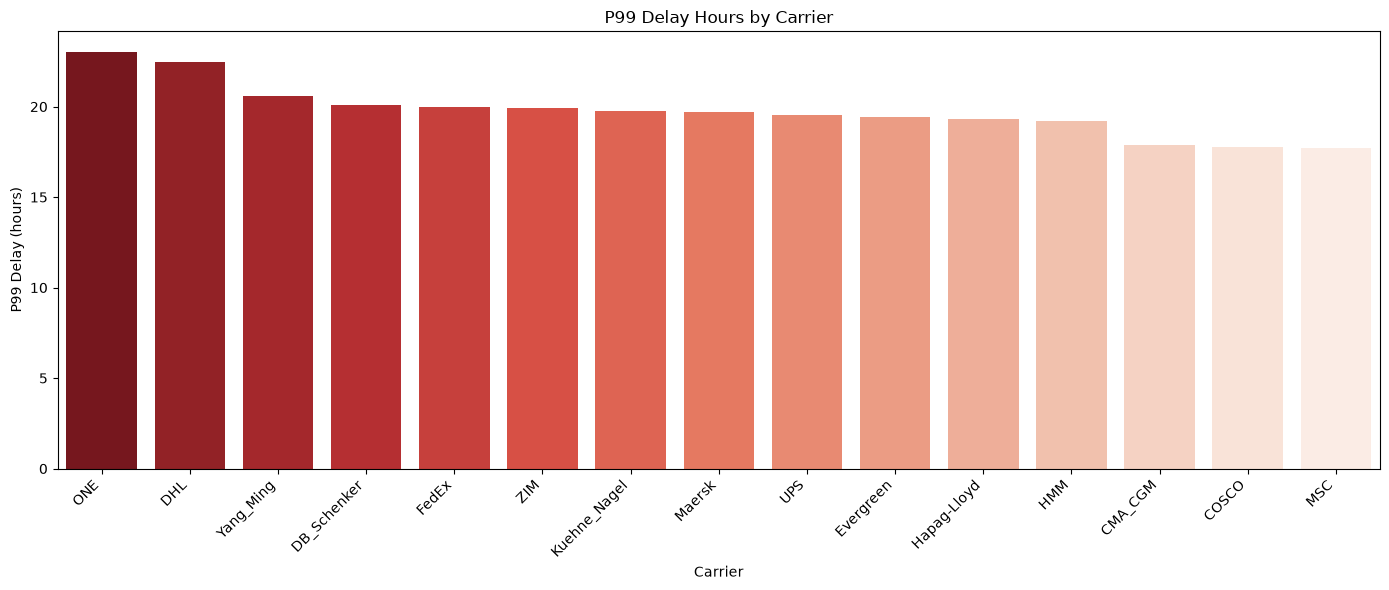

In [40]:
carrier_p99=(
    df.groupby('carrier')['delay_hours']
      .quantile(0.99)
      .sort_values(ascending=False)
)
plt.figure(figsize=(14,6))
sns.barplot(x=carrier_p99.index,y=carrier_p90.values,palette='Reds_r')
plt.xticks(rotation=45, ha='right')
plt.title('P99 Delay Hours by Carrier')
plt.ylabel('P99 Delay (hours)')
plt.xlabel('Carrier')
plt.tight_layout()
plt.show()

In [30]:
origin_p90=(
    df.groupby('origin_port')['delay_hours']
      .quantile(0.90)
      .sort_values(ascending=False)
)
origin_p95=(
    df.groupby('origin_port')['delay_hours']
      .quantile(0.95)
      .sort_values(ascending=False)
)
origin_p99=(
    df.groupby('origin_port')['delay_hours']
      .quantile(0.99)
      .sort_values(ascending=False)
)

C:\Users\jenny\AppData\Local\Temp\ipykernel_3192\2734199898.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=origin_p90.index,y=origin_p90.values,palette='Blues_r')


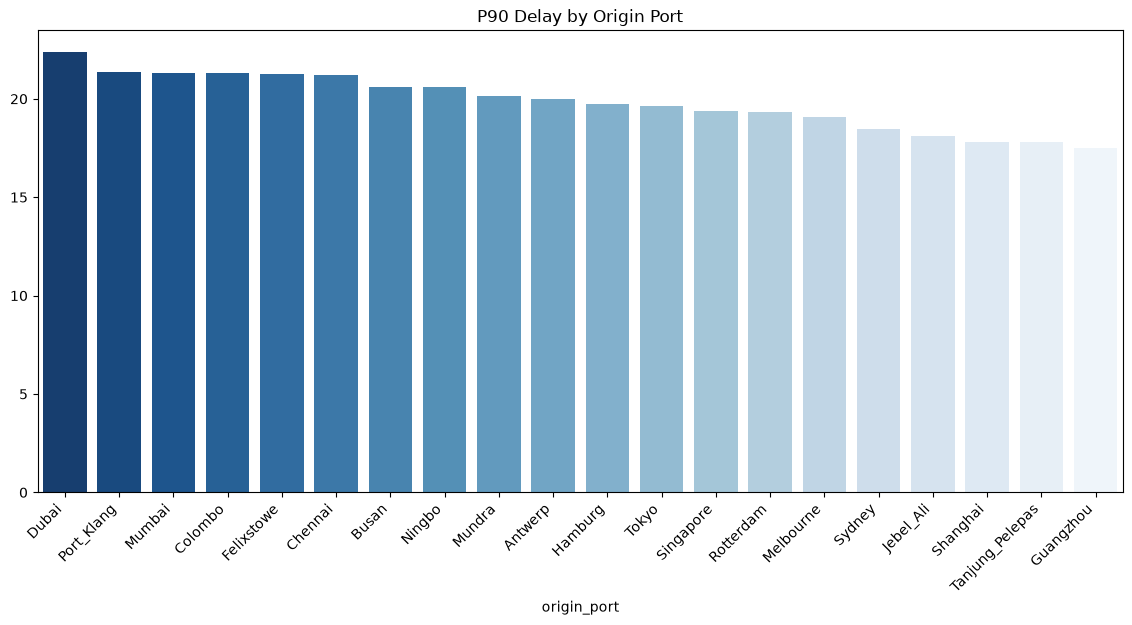

In [41]:
plt.figure(figsize=(14,6))
sns.barplot(x=origin_p90.index,y=origin_p90.values,palette='Blues_r')
plt.xticks(rotation=45,ha='right')
plt.title('P90 Delay by Origin Port')
plt.show()

C:\Users\jenny\AppData\Local\Temp\ipykernel_3192\2796387729.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=origin_p95.index,y=origin_p95.values,palette='Greens_r')


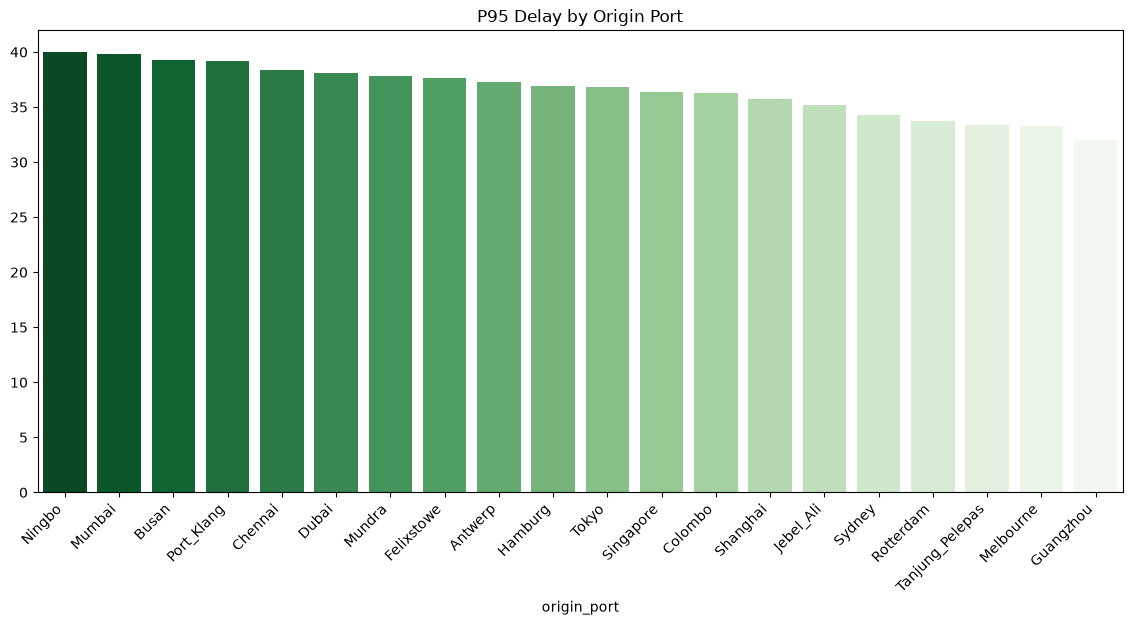

In [42]:
plt.figure(figsize=(14,6))
sns.barplot(x=origin_p95.index,y=origin_p95.values,palette='Greens_r')
plt.xticks(rotation=45,ha='right')
plt.title('P95 Delay by Origin Port')
plt.show()

C:\Users\jenny\AppData\Local\Temp\ipykernel_3192\2172397343.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=origin_p99.index,y=origin_p99.values,palette='Reds_r')


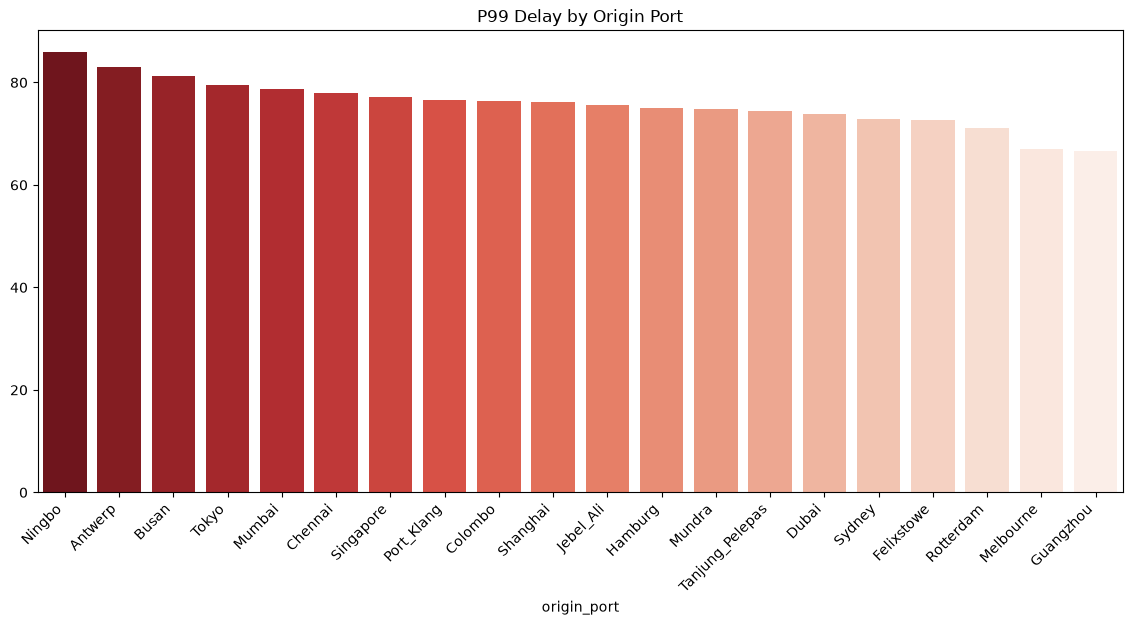

In [37]:
plt.figure(figsize=(14,6))
sns.barplot(x=origin_p99.index,y=origin_p99.values,palette='Reds_r')
plt.xticks(rotation=45,ha='right')
plt.title('P99 Delay by Origin Port')
plt.show()

In [45]:
dest_p90=(
    df.groupby('destination_port')['delay_hours']
      .quantile(0.90)
      .sort_values(ascending=False)
)
dest_p95=(
    df.groupby('destination_port')['delay_hours']
      .quantile(0.95)
      .sort_values(ascending=False)
)
dest_p99=(
    df.groupby('destination_port')['delay_hours']
      .quantile(0.99)
      .sort_values(ascending=False)
)

C:\Users\jenny\AppData\Local\Temp\ipykernel_3192\2363621331.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dest_p90.index,y=dest_p90.values,palette='Blues_r')


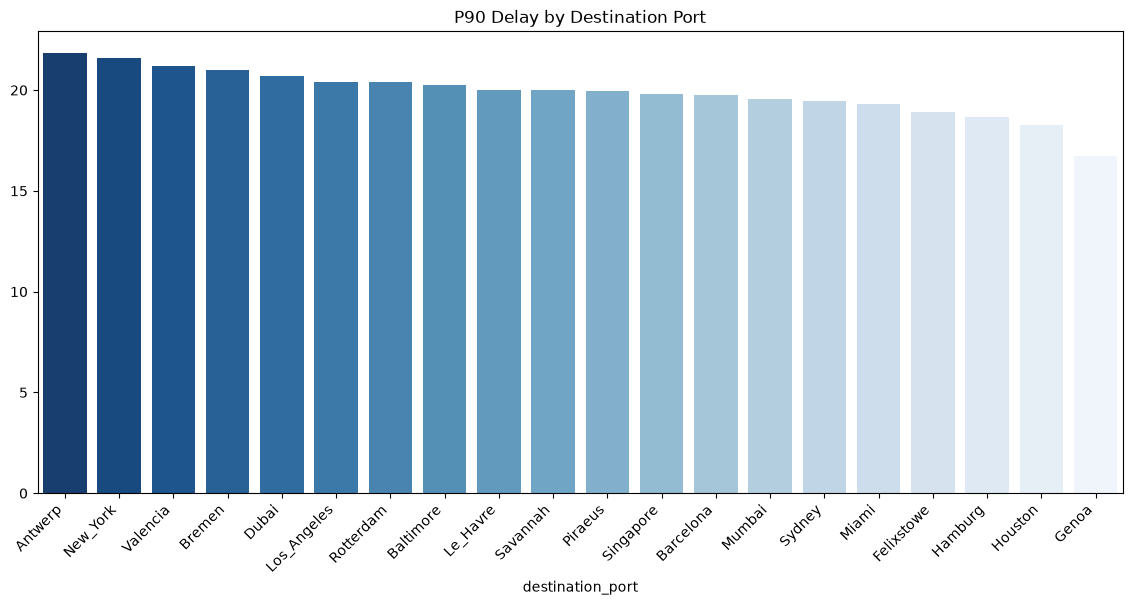

In [46]:
plt.figure(figsize=(14,6))
sns.barplot(x=dest_p90.index,y=dest_p90.values,palette='Blues_r')
plt.xticks(rotation=45,ha='right')
plt.title('P90 Delay by Destination Port')
plt.show()

C:\Users\jenny\AppData\Local\Temp\ipykernel_3192\3413147546.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dest_p95.index,y=dest_p95.values,palette='Greens_r')


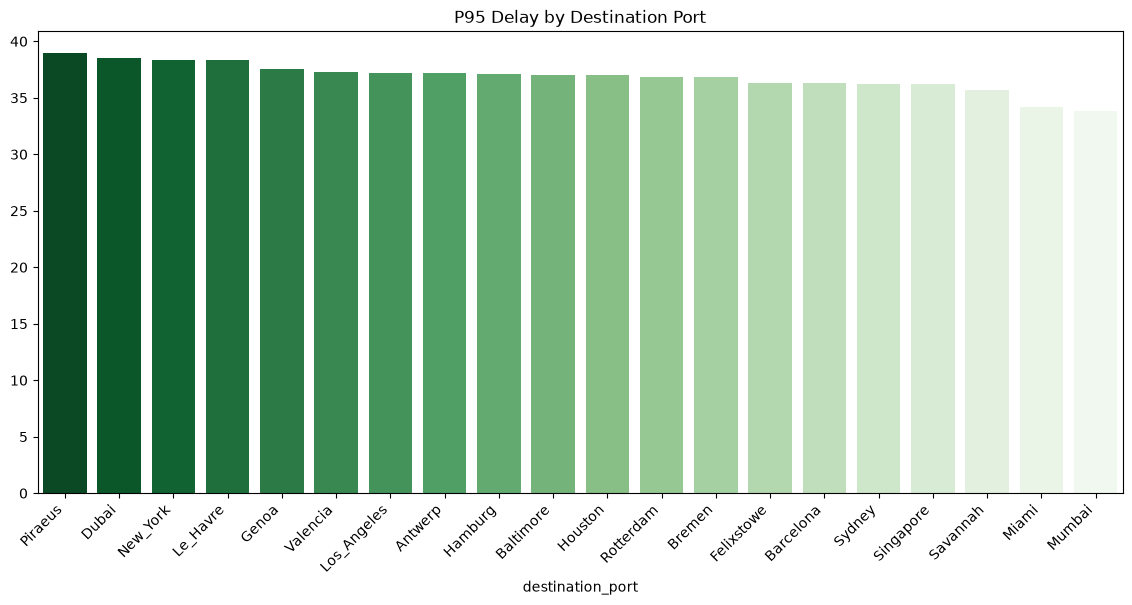

In [47]:
plt.figure(figsize=(14,6))
sns.barplot(x=dest_p95.index,y=dest_p95.values,palette='Greens_r')
plt.xticks(rotation=45,ha='right')
plt.title('P95 Delay by Destination Port')
plt.show()

C:\Users\jenny\AppData\Local\Temp\ipykernel_3192\2670044268.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dest_p99.index,y=dest_p99.values,palette='Reds_r')


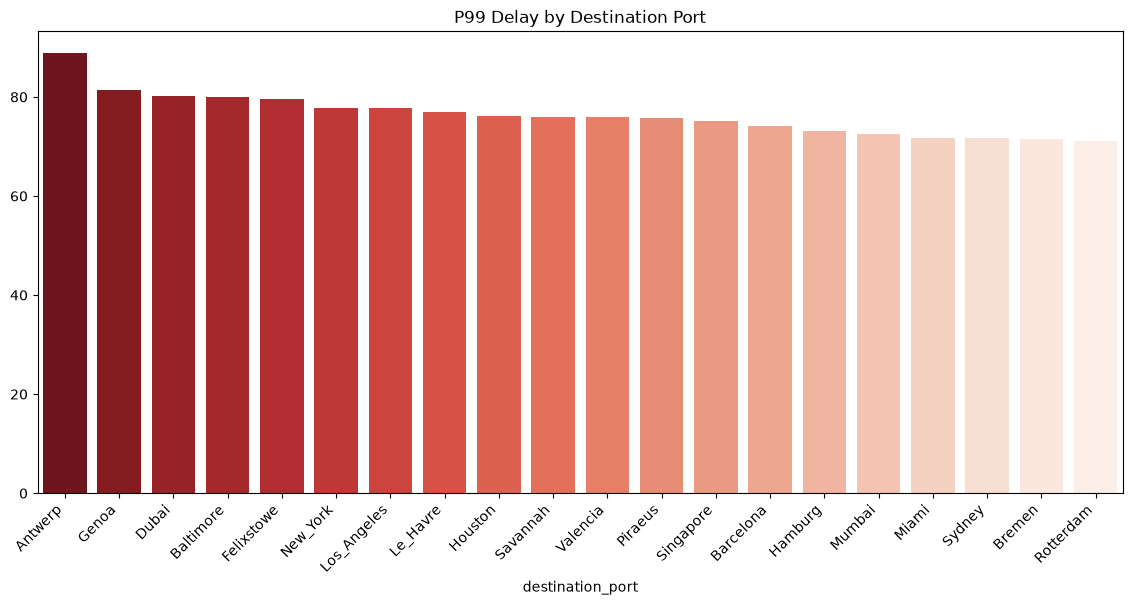

In [48]:
plt.figure(figsize=(14,6))
sns.barplot(x=dest_p99.index,y=dest_p99.values,palette='Reds_r')
plt.xticks(rotation=45,ha='right')
plt.title('P99 Delay by Destination Port')
plt.show()

In [49]:
od_p90=(
    df.groupby(['origin_port', 'destination_port'])['delay_hours']
      .quantile(0.90)
      .unstack()
)

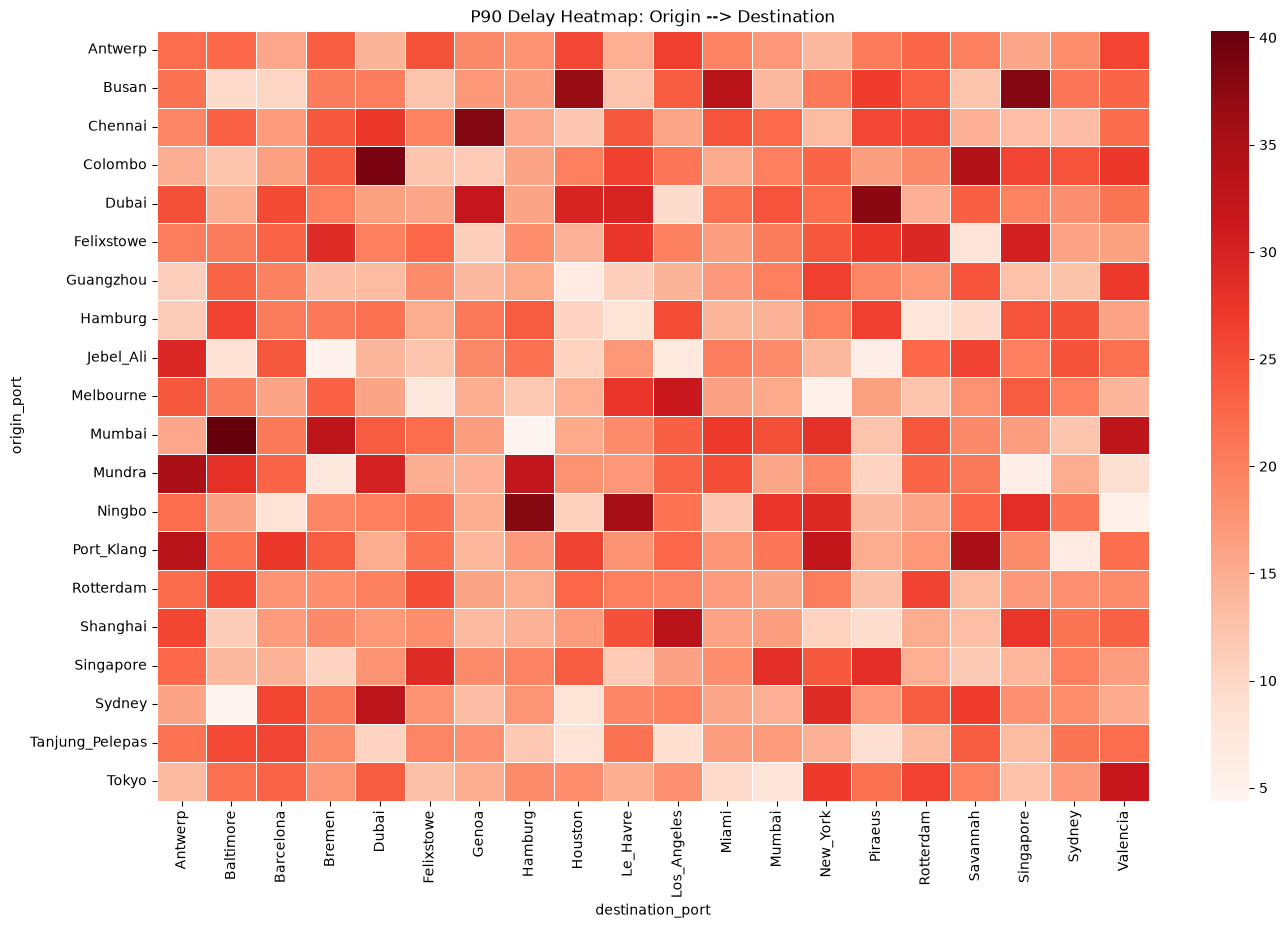

In [52]:
plt.figure(figsize=(16,10))
sns.heatmap(od_p90, cmap='Reds', linewidths=.5)
plt.title('P90 Delay Heatmap: Origin --> Destination')
plt.show()

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df=pd.read_csv('cleaned_shipments.csv')

In [14]:
median_delays = df.groupby('carrier')['delay_hours'].median().reset_index()